# Projeto Machine Learning

#### Membros do grupo : Pedro Garcia e Pedro Machado

#### APS 1 : entrega 10/03


# EDA - Adult Census Income Dataset

**Dataset:** [Adult Census Income](https://archive.ics.uci.edu/ml/datasets/Adult) da UCI Machine Learning Repository

**Objetivo:** Prever se a renda anual de um indivíduo excede $50K/ano com base em dados do censo.

Este notebook realiza uma análise exploratória abrangente para entender a estrutura, qualidade, distribuições e relações entre variáveis.

In [32]:
# imports e config de plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pathlib import Path

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Carregamento e Inspeção Inicial dos Dados

### 1.1 Carregamento dos dados

In [33]:
# carrega adult.data + adult.test e concatena
COLUNAS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

def carregar_dataset(base_path: str = '.') -> pd.DataFrame:
    base = Path(base_path)
    df_train = pd.read_csv(base / 'adult.data', names=COLUNAS, na_values='?', skipinitialspace=True)
    df_test = pd.read_csv(base / 'adult.test', names=COLUNAS, na_values='?', skipinitialspace=True, skiprows=1)
    df_test['income'] = df_test['income'].str.rstrip('.')
    return pd.concat([df_train, df_test], ignore_index=True)

df = carregar_dataset()
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


### 1.2 Descrição das Features

| Feature | Tipo | Descrição |
|---------|------|-----------|
| **age** | Numérico (contínuo) | Idade do indivíduo em anos |
| **workclass** | Categórico | Classe de trabalho: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked |
| **fnlwgt** | Numérico (contínuo) | Peso final do censo - representa o número de pessoas que a instância representa na população |
| **education** | Categórico | Nível de educação: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool |
| **education-num** | Numérico (contínuo) | Número numérico que representa o nível de educação (1-16) |
| **marital-status** | Categórico | Estado civil: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse |
| **occupation** | Categórico | Ocupação: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces |
| **relationship** | Categórico | Relação familiar: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried |
| **race** | Categórico | Raça: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black |
| **sex** | Categórico (binário) | Sexo: Female, Male |
| **capital-gain** | Numérico (contínuo) | Ganho de capital em dólares |
| **capital-loss** | Numérico (contínuo) | Perda de capital em dólares |
| **hours-per-week** | Numérico (contínuo) | Horas trabalhadas por semana |
| **native-country** | Categórico | País de origem |
| **income** | Categórico (target) | Renda <=50K ou >50K |

In [34]:
# dimensões do dataset
print(f"Número de instâncias: {len(df):,}")
print(f"Número de features (incluindo target): {len(df.columns)}")
print(f"Features: {list(df.columns)}")

Número de instâncias: 48,842
Número de features (incluindo target): 15
Features: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [35]:
# numéricas vs categóricas
print("Tipos de dados:")
print(df.dtypes)
print("\n" + "="*60)
print("Variáveis NUMÉRICAS:", df.select_dtypes(include=[np.number]).columns.tolist())
print("Variáveis CATEGÓRICAS:", df.select_dtypes(include=['object']).columns.tolist())

Tipos de dados:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Variáveis NUMÉRICAS: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variáveis CATEGÓRICAS: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [36]:
# checagem de missing
print("Valores ausentes por coluna:")
missing = df.isna().sum()
print(missing[missing > 0])
print("\nTotal de valores ausentes:", df.isna().sum().sum())

Valores ausentes por coluna:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Total de valores ausentes: 6465


Distribuição do target 'income':
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Proporções:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


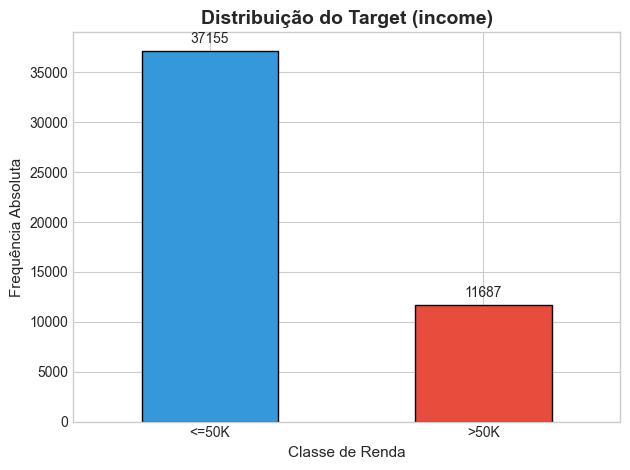

In [37]:
# distribuição do target e gráfico
print("Distribuição do target 'income':")
print(df['income'].value_counts())
print("\nProporções:")
print(df['income'].value_counts(normalize=True).round(4))

ax = df['income'].value_counts().plot(kind='bar', rot=0, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Distribuição do Target (income)', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe de Renda', fontsize=11)
ax.set_ylabel('Frequência Absoluta', fontsize=11)
for i, v in enumerate(df['income'].value_counts()):
    ax.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Análise Univariada

### 2.1 Variáveis Numéricas: Estatísticas Descritivas

In [38]:
# estatísticas descritivas das numéricas
numericas = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df[numericas].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


In [39]:
# mean, median, std por variável
stats = df[numericas].agg(['mean', 'median', 'std']).round(2)
stats.T

,mean,median,std
age,38.64,37.0,13.71
fnlwgt,189664.13,178144.5,105604.03
education-num,10.08,10.0,2.57
capital-gain,1079.07,0.0,7452.02
capital-loss,87.50,0.0,403.00
hours-per-week,40.42,40.0,12.39


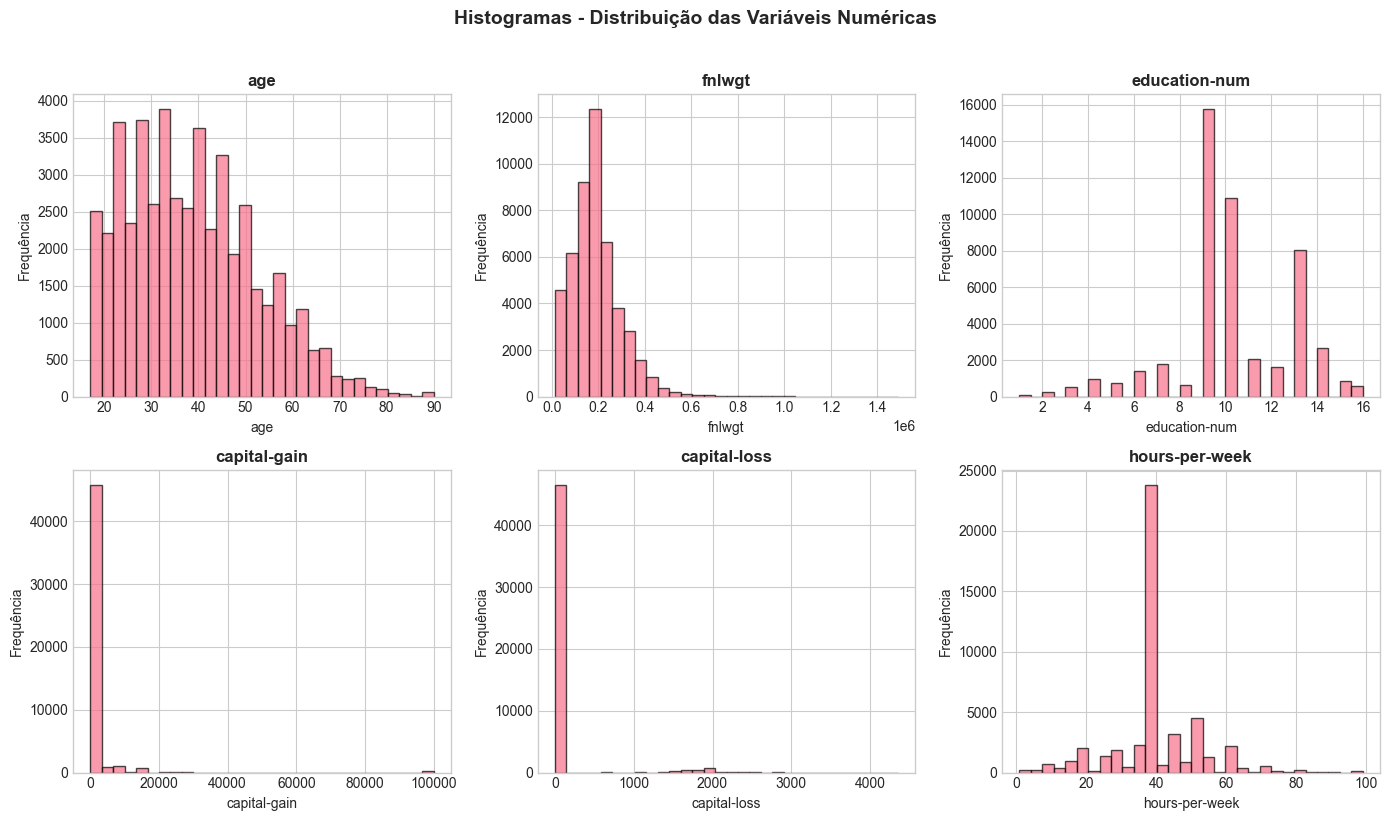

In [40]:
# histogramas das variáveis numéricas
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numericas):
    df[col].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequência', fontsize=10)
plt.suptitle('Histogramas - Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

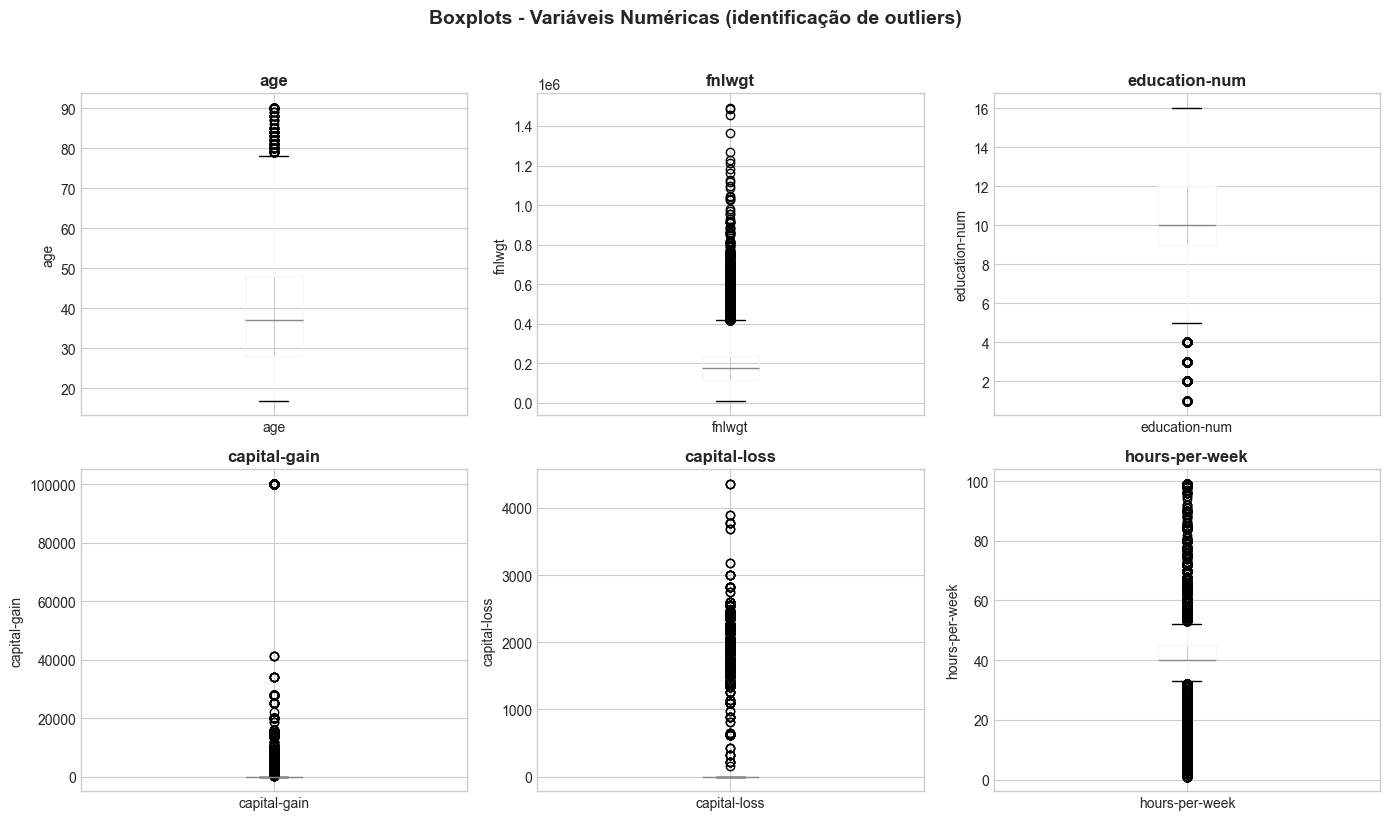

In [41]:
# boxplots das numéricas
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numericas):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)
plt.suptitle('Boxplots - Variáveis Numéricas (identificação de outliers)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# outliers por z-score (|z| > 3)
outliers_z = {}
for col in numericas:
    vals = df[col].dropna()
    z = np.abs((vals - vals.mean()) / vals.std())
    outliers_z[col] = (z > 3).sum()
pd.Series(outliers_z).to_frame('Outliers (|z|>3)')

,Outliers (|z|>3)
age,186
fnlwgt,506
education-num,330
capital-gain,331
capital-loss,2216
hours-per-week,681


### 2.2 Variáveis Categóricas: Frequências e Gráficos de Barras

In [43]:
# variáveis categóricas para análise
categoricas = ['workclass', 'education', 'marital-status', 'occupation', 
               'relationship', 'race', 'sex', 'native-country']

for col in categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialt

C:\Users\pedro\AppData\Local\Temp\ipykernel_7728\2969229656.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('income', group_keys=False).apply(


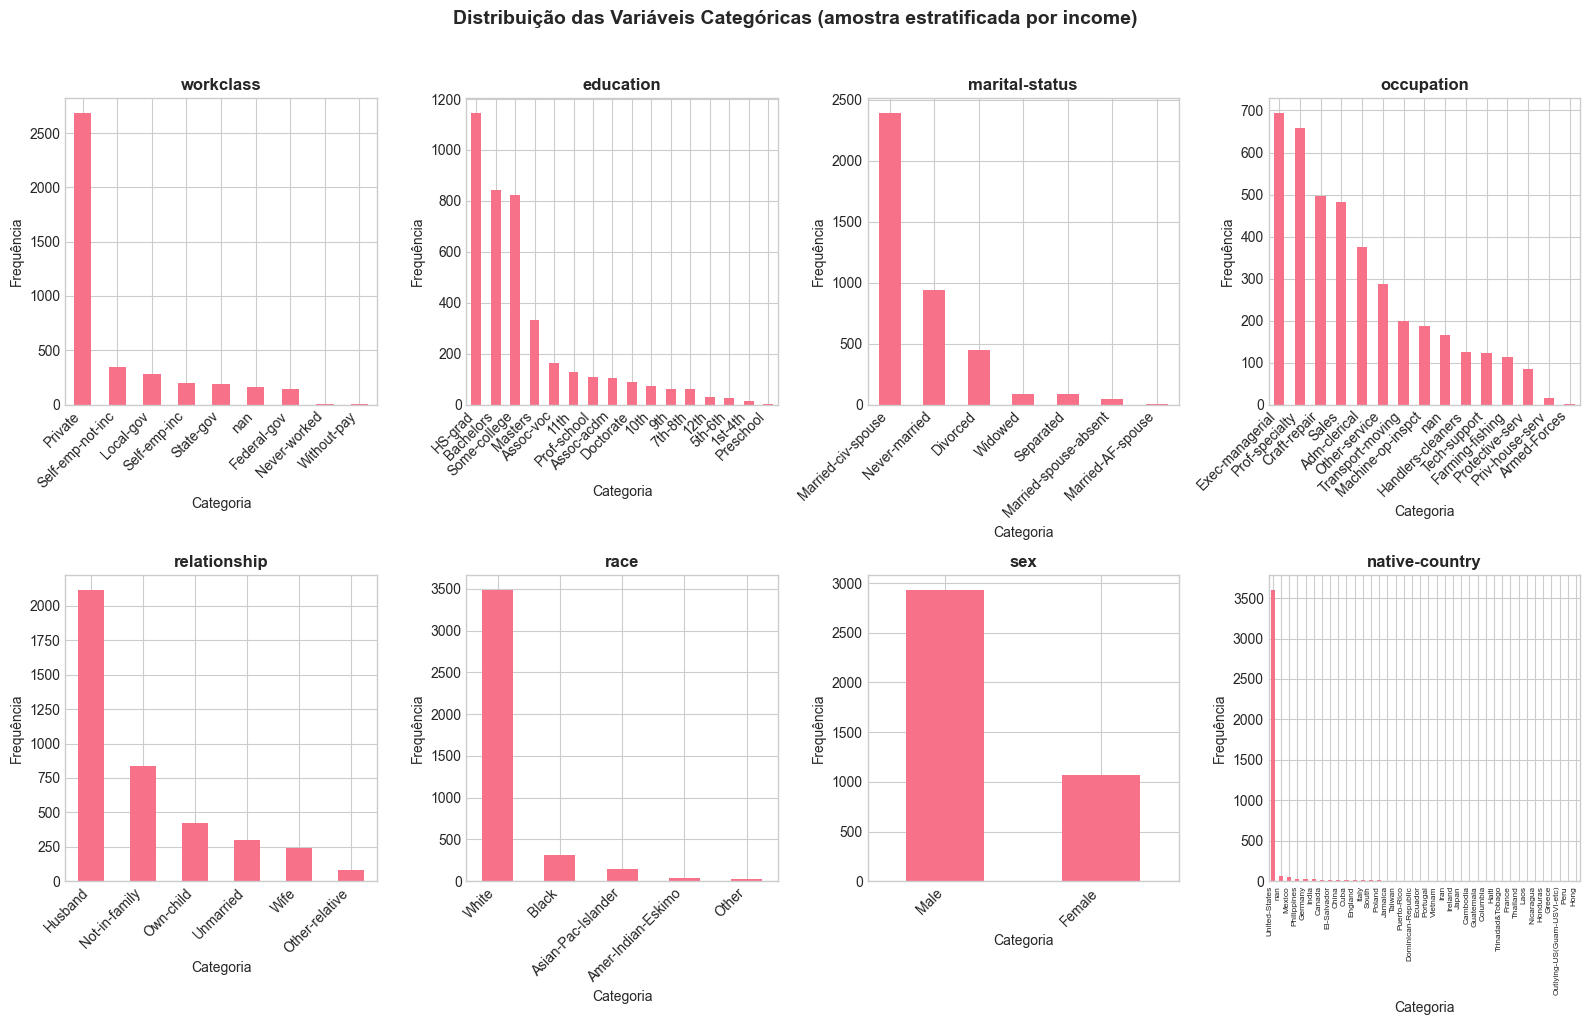

In [44]:
# amostra balanceada por income (max 2000 por classe) para plots
df_sample = df.groupby('income', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2000), random_state=42)
).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(categoricas):
    if col == 'native-country':
        df_sample[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], rot=90)
        plt.setp(axes[i].get_xticklabels(), ha='right', fontsize=6)
    else:
        df_sample[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], rot=45)
        plt.setp(axes[i].get_xticklabels(), ha='right')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Categoria', fontsize=10)
    axes[i].set_ylabel('Frequência', fontsize=10)
plt.suptitle('Distribuição das Variáveis Categóricas (amostra estratificada por income)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Análise Bivariada e Multivariada

### 3.1 Correlações entre Variáveis Numéricas

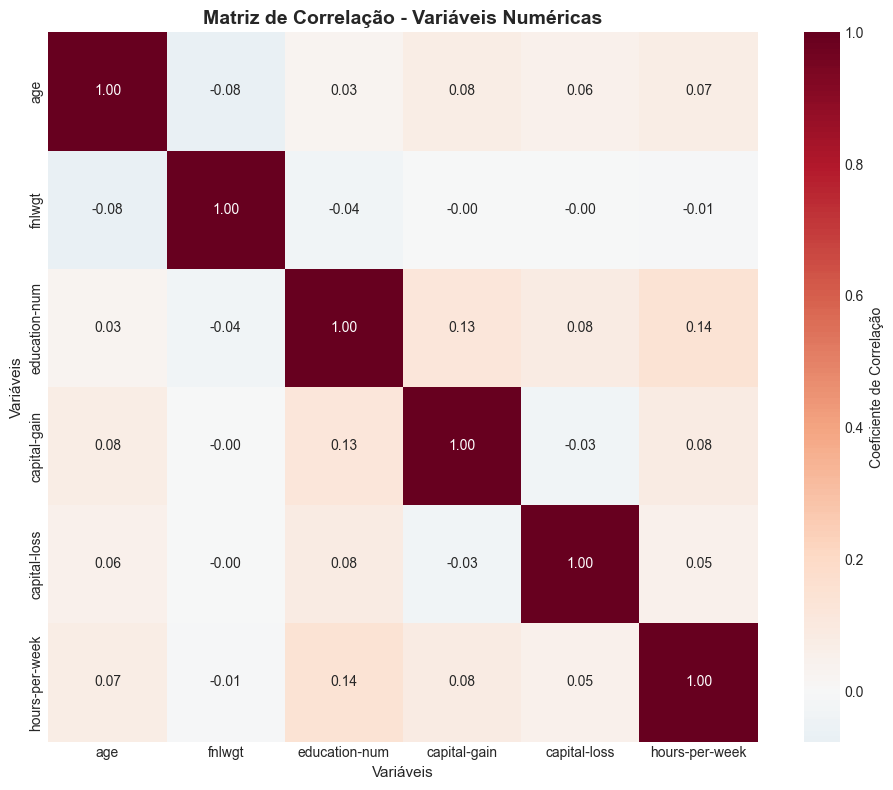

In [45]:
# matriz de correlação das numéricas
corr = df[numericas].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, 
            ax=ax, cbar_kws={'label': 'Coeficiente de Correlação'})
ax.set_title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
ax.set_xlabel('Variáveis', fontsize=11)
ax.set_ylabel('Variáveis', fontsize=11)
plt.tight_layout()
plt.show()

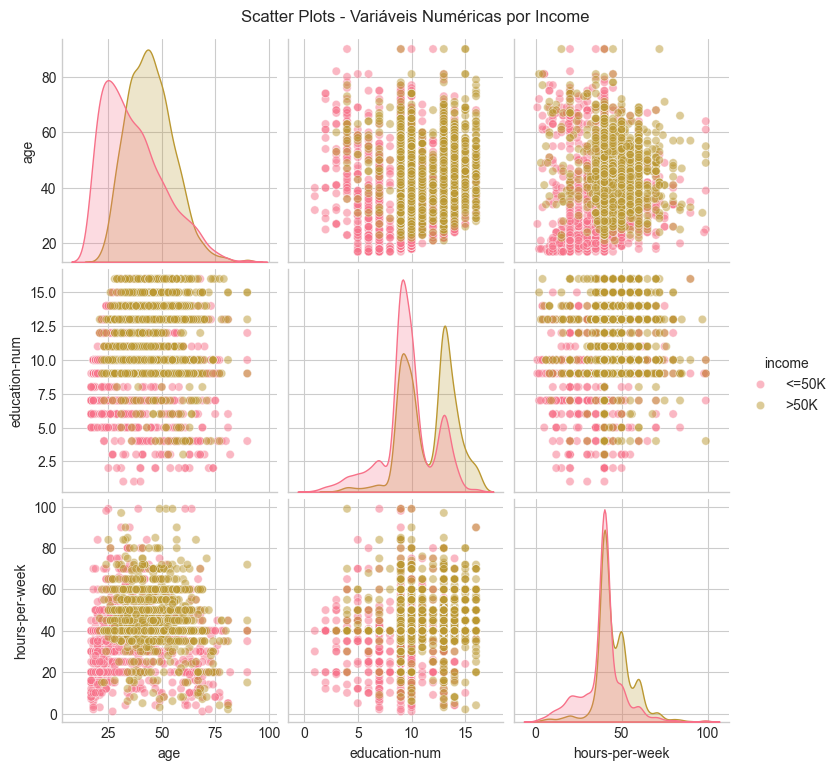

In [46]:
# pairplot colorido por income (amostra)
sample = df_sample[numericas + ['income']]
sns.pairplot(sample, hue='income', vars=['age', 'education-num', 'hours-per-week'], 
             diag_kind='kde', plot_kws={'alpha': 0.5}, height=2.5)
plt.suptitle('Scatter Plots - Variáveis Numéricas por Income', y=1.02)
plt.show()

### 3.2 Relações entre Variáveis Categóricas e o Target 'income'

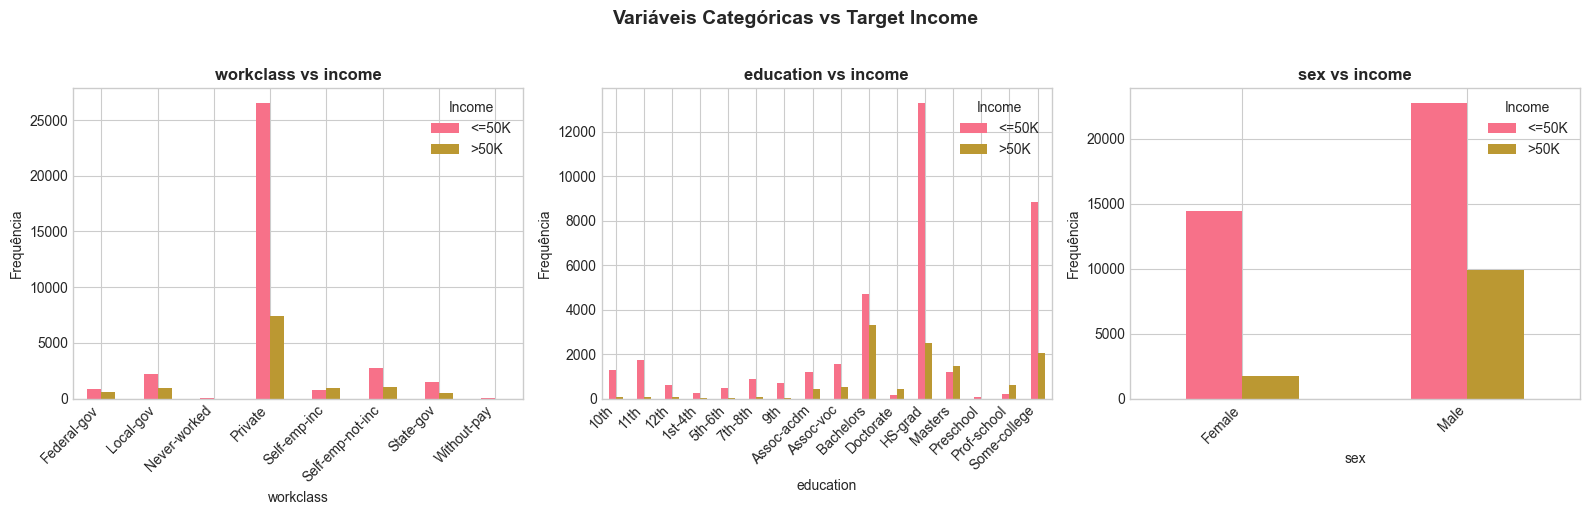

In [47]:
# barras das top categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['workclass', 'education', 'sex']):
    crosstab = pd.crosstab(df[col], df['income'])
    crosstab.plot(kind='bar', ax=ax, stacked=False, rot=45)
    plt.setp(ax.get_xticklabels(), ha='right')
    ax.set_title(f'{col} vs income', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.legend(title='Income', loc='upper right')
plt.suptitle('Variáveis Categóricas vs Target Income', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [48]:
# helper: % de >50K em cada grupo
def proporcao_maior_50k(serie):
    return (serie == '>50K').mean()

print("Proporção de income >50K por categoria:")
for col in categoricas:
    prop = df.groupby(col)['income'].apply(proporcao_maior_50k).sort_values(ascending=False)
    print(f"\n{col}:")
    print(prop.round(3).to_string())

Proporção de income >50K por categoria:

workclass:
workclass
Self-emp-inc        0.553
Federal-gov         0.392
Local-gov           0.296
Self-emp-not-inc    0.279
State-gov           0.268
Private             0.218
Without-pay         0.095
Never-worked        0.000

education:
education
Prof-school     0.740
Doctorate       0.726
Masters         0.549
Bachelors       0.413
Assoc-acdm      0.258
Assoc-voc       0.253
Some-college    0.190
HS-grad         0.159
12th            0.073
7th-8th         0.065
10th            0.063
9th             0.054
5th-6th         0.053
11th            0.051
1st-4th         0.032
Preschool       0.012

marital-status:
marital-status
Married-civ-spouse       0.446
Married-AF-spouse        0.378
Divorced                 0.101
Married-spouse-absent    0.092
Widowed                  0.084
Separated                0.065
Never-married            0.045

occupation:
occupation
Exec-managerial      0.478
Prof-specialty       0.451
Armed-Forces         0.333
Pr

### 3.3 Relações entre Variáveis Numéricas e Categóricas (Boxplots / Violin Plots)

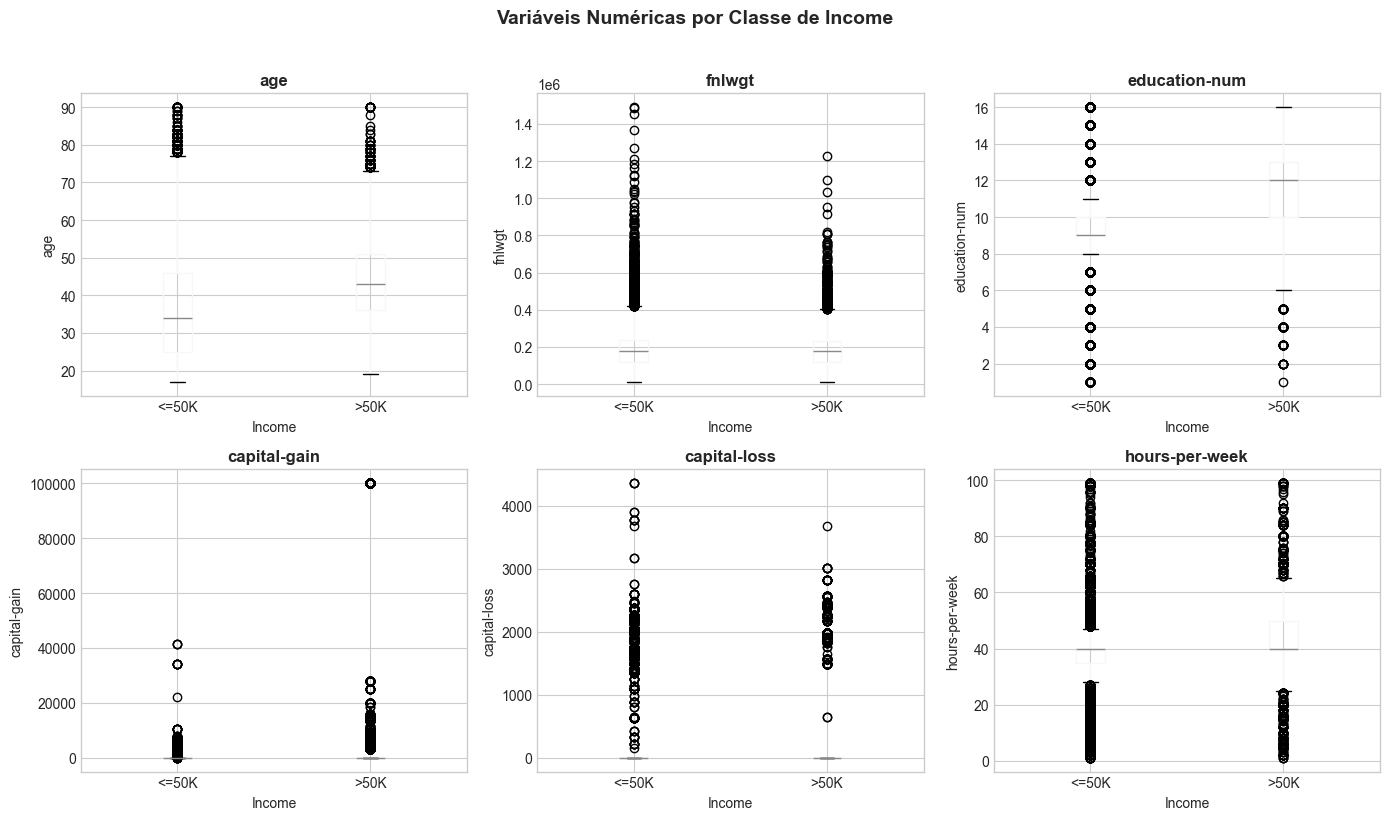

In [49]:
# boxplots numéricas por income
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numericas):
    df.boxplot(column=col, by='income', ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Income', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
fig.suptitle('')
plt.suptitle('Variáveis Numéricas por Classe de Income', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

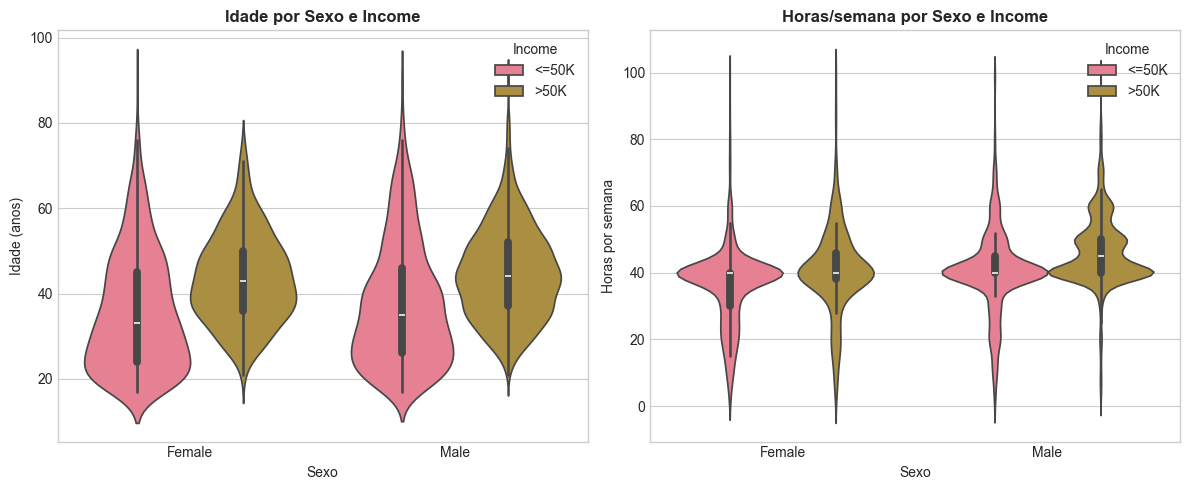

In [50]:
# violin: age e hours por sex/income
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df_sample, x='sex', y='age', hue='income', split=False, ax=axes[0])
axes[0].set_title('Idade por Sexo e Income', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sexo', fontsize=10)
axes[0].set_ylabel('Idade (anos)', fontsize=10)
axes[0].legend(title='Income', loc='upper right')
sns.violinplot(data=df_sample, x='sex', y='hours-per-week', hue='income', split=False, ax=axes[1])
axes[1].set_title('Horas/semana por Sexo e Income', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sexo', fontsize=10)
axes[1].set_ylabel('Horas por semana', fontsize=10)
axes[1].legend(title='Income', loc='upper right')
plt.tight_layout()
plt.show()

## 4. Análise de Qualidade dos Dados

### 4.1 Valores Ausentes

In [51]:
# resumo de missing (% por coluna)
missing_summary = df.isna().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Ausentes': missing_summary,
    'Percentual (%)': missing_pct
}).loc[missing_summary > 0]
print("Valores ausentes por coluna:")
print(missing_df)
print(f"\nTotal de linhas com pelo menos um valor ausente: {df.isna().any(axis=1).sum():,}")

Valores ausentes por coluna:
                Ausentes  Percentual (%)
workclass           2799            5.73
occupation          2809            5.75
native-country       857            1.75

Total de linhas com pelo menos um valor ausente: 3,620


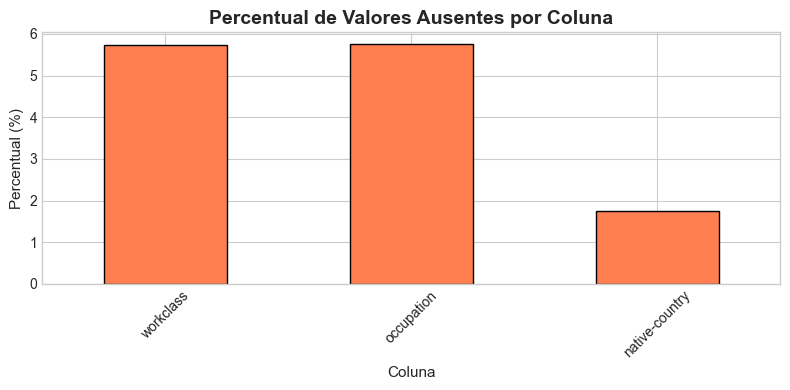

In [52]:
# gráfico de barras das colunas com missing
cols_com_missing = missing_summary[missing_summary > 0]
if len(cols_com_missing) > 0:
    ax = (cols_com_missing / len(df) * 100).plot(kind='bar', figsize=(8, 4), rot=45, color='coral', edgecolor='black')
    ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentual (%)', fontsize=11)
    ax.set_xlabel('Coluna', fontsize=11)
    plt.tight_layout()
    plt.show()

### 4.2 Desequilíbrio de Classes no Target

In [53]:
# razão de desequilíbrio entre classes
class_counts = df['income'].value_counts()
ratio = class_counts.max() / class_counts.min()
print(f"Proporção <=50K: {(df['income'] == '<=50K').mean():.2%}")
print(f"Proporção >50K: {(df['income'] == '>50K').mean():.2%}")
print(f"Razão de desequilíbrio (maior/menor): {ratio:.2f}:1")
print("\nO dataset está desequilibrado (~76% vs ~24%). Recomenda-se: estratificação, oversampling/undersampling ou ponderação de classes na modelagem.")

Proporção <=50K: 76.07%
Proporção >50K: 23.93%
Razão de desequilíbrio (maior/menor): 3.18:1

O dataset está desequilibrado (~76% vs ~24%). Recomenda-se: estratificação, oversampling/undersampling ou ponderação de classes na modelagem.


### 4.3 Vieses e Inconsistências Potenciais

In [54]:
# mapeamento education -> education-num (redundância)
edu_map = df.dropna(subset=['education', 'education-num']).groupby('education')['education-num'].agg(['min', 'max', 'nunique'])
print("Consistência education <-> education-num:")
print(edu_map)
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")
print("\nValores suspeitos:")
print(f"  age: min={df['age'].min()}, max={df['age'].max()} (esperado: 17-90+)")
print(f"  hours-per-week: min={df['hours-per-week'].min()}, max={df['hours-per-week'].max()} (esperado: 1-99)")

Consistência education <-> education-num:
              min  max  nunique
education                      
10th            6    6        1
11th            7    7        1
12th            8    8        1
1st-4th         2    2        1
5th-6th         3    3        1
7th-8th         4    4        1
9th             5    5        1
Assoc-acdm     12   12        1
Assoc-voc      11   11        1
Bachelors      13   13        1
Doctorate      16   16        1
HS-grad         9    9        1
Masters        14   14        1
Preschool       1    1        1
Prof-school    15   15        1
Some-college   10   10        1

Linhas duplicadas: 52

Valores suspeitos:
  age: min=17, max=90 (esperado: 17-90+)
  hours-per-week: min=1, max=99 (esperado: 1-99)


In [55]:
# % >50K por sexo e raça
print("Proporção >50K por sexo:")
print(df.groupby('sex')['income'].apply(proporcao_maior_50k).round(3))
print("\nProporção >50K por raça:")
print(df.groupby('race')['income'].apply(proporcao_maior_50k).sort_values(ascending=False).round(3))
print("\nNota: O dataset reflete disparidades históricas do censo de 1994. Cuidado com vieses em modelos de ML.")

Proporção >50K por sexo:
sex
Female    0.109
Male      0.304
Name: income, dtype: float64

Proporção >50K por raça:
race
Asian-Pac-Islander    0.269
White                 0.254
Other                 0.123
Black                 0.121
Amer-Indian-Eskimo    0.117
Name: income, dtype: float64

Nota: O dataset reflete disparidades históricas do censo de 1994. Cuidado com vieses em modelos de ML.


## 5. Estratégias de Pré-processamento (Justificadas pela EDA)

Com base nos achados da análise exploratória, propõe-se as seguintes estratégias utilizando **Scikit-learn**:

| Desafio | Achado da EDA | Estratégia com Scikit-learn |
|---------|---------------|------------------------------|
| **Valores ausentes** | workclass, occupation e native-country possuem ~5-6% de missing | `SimpleImputer(strategy='most_frequent')` para categóricas; testar remoção e comparar métricas |
| **Desequilíbrio de classes** | ~76% <=50K vs ~24% >50K (razão ~3:1) | `train_test_split(..., stratify=y)`; `class_weight='balanced'` em modelos; ou `SMOTE` do imbalanced-learn |
| **Redundância** | education e education-num altamente correlacionados (corr > 0.95) | Remover `education` categórico; manter apenas `education-num` no pipeline |
| **Outliers** | capital-gain e capital-loss com muitos outliers (|z|>3) | Manter valores (informativos); ou `FunctionTransformer` com `np.log1p` para suavizar |
| **Encoding** | 8 variáveis categóricas | `OneHotEncoder(drop='first')` via `ColumnTransformer`; reduz dimensionalidade |
| **Escalonamento** | Variáveis numéricas em escalas diferentes (age: 17-90, fnlwgt: 13k-1.4M) | `StandardScaler` no `ColumnTransformer` para normalização; essencial para modelos lineares/SVM |

In [56]:
# prep: impute, scale, one-hot; separa X e y
X = df.drop('income', axis=1)
y = df['income']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

numericas_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categoricas_features = ['workclass', 'marital-status', 'occupation', 
                       'relationship', 'race', 'sex', 'native-country']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numericas_features),
        ('cat', cat_pipeline, categoricas_features)
    ],
    remainder='drop'
)

X_preprocessed = preprocessor.fit_transform(X)
print(f"Shape após pré-processamento: {X_preprocessed.shape}")
print(f"Features numéricas escaladas: {len(numericas_features)}")
print(f"Features categóricas codificadas (OneHot): {X_preprocessed.shape[1] - len(numericas_features)}")
print("\nPipeline pronto para modelagem com fit/transform em train e apenas transform em test.")

Shape após pré-processamento: (48842, 82)
Features numéricas escaladas: 6
Features categóricas codificadas (OneHot): 76

Pipeline pronto para modelagem com fit/transform em train e apenas transform em test.


## 6. Redução de Dimensionalidade

Aplicamos **PCA** e **t-SNE** para visualizar a estrutura dos dados e avaliar a separabilidade das classes. O PCA reduz dimensionalidade preservando variância; o t-SNE preserva estruturas locais para visualização 2D.

Componentes PCA para 95% variância: 22
Variância explicada cumulativa: [0.164 0.286 0.402 0.514 0.616]...


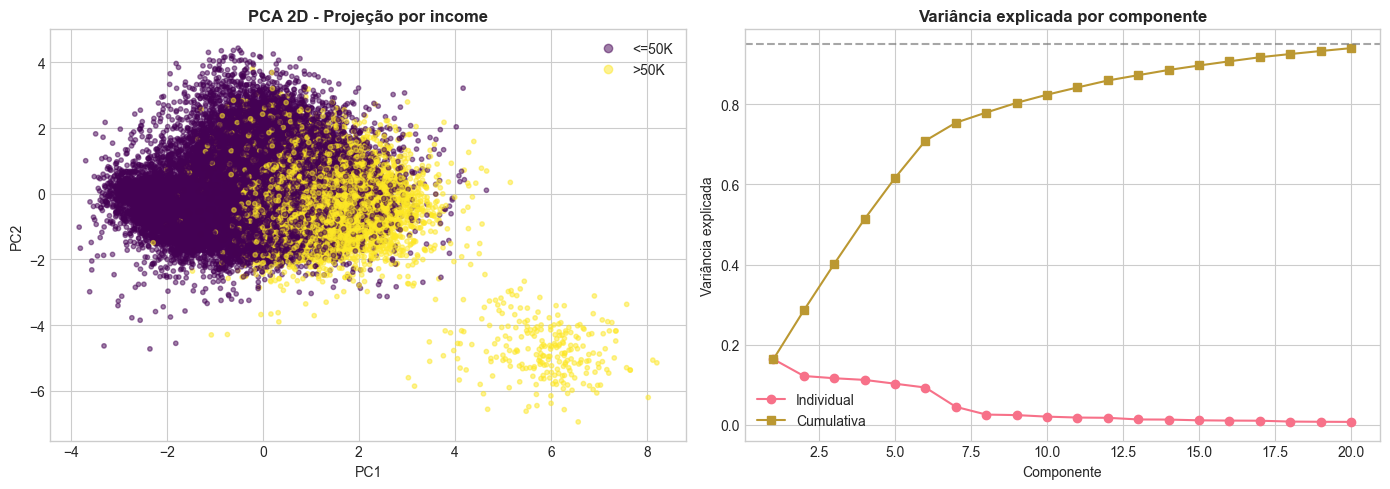

In [57]:
# PCA mantendo 95% da variância
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)
print(f"Componentes PCA para 95% variância: {pca.n_components_}")
print(f"Variância explicada cumulativa: {pca.explained_variance_ratio_.cumsum()[:5].round(3)}...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('PCA 2D - Projeção por income', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(handles=scatter.legend_elements()[0], labels=['<=50K', '>50K'], loc='upper right')
n_plot = min(20, pca.n_components_)
axes[1].plot(range(1, n_plot + 1), pca.explained_variance_ratio_[:n_plot], 'o-', label='Individual')
axes[1].plot(range(1, n_plot + 1), pca.explained_variance_ratio_[:n_plot].cumsum(), 's-', label='Cumulativa')
axes[1].set_title('Variância explicada por componente', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Variância explicada')
axes[1].legend()
axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


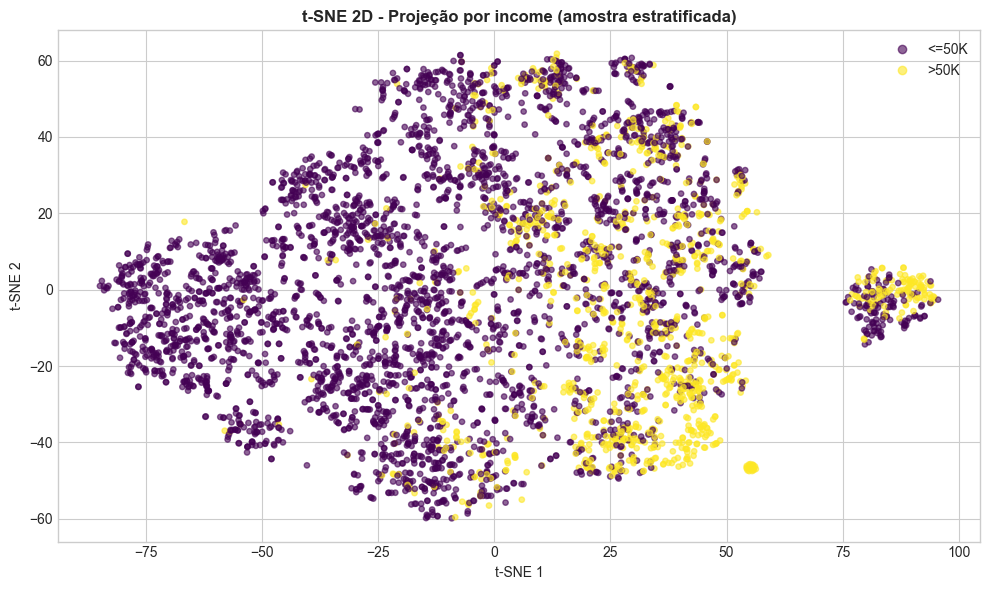

In [58]:
# t-SNE em amostra (lento em dataset grande)
sample_idx, _ = train_test_split(np.arange(len(X_preprocessed)), test_size=0.9, stratify=y_encoded, random_state=42)
X_tsne_sample = X_preprocessed[sample_idx]
y_tsne_sample = y_encoded[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_sample)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tsne_sample, cmap='viridis', alpha=0.6, s=15)
ax.set_title('t-SNE 2D - Projeção por income (amostra estratificada)', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(handles=scatter.legend_elements()[0], labels=['<=50K', '>50K'], loc='upper right')
plt.tight_layout()
plt.show()

## 7. Documentação e Apresentação

### 7.1 Feature Engineering (sugestões baseadas na EDA)

- **Idade em grupos:** Criar bins (ex: 18-30, 31-45, 46-60, 60+) para capturar relações não-lineares com income.
- **Interação education-num × hours-per-week:** Pessoas com mais educação e mais horas podem ter maior renda.
- **Capital total:** `capital-gain - capital-loss` para uma única variável de capital.
- **Razão horas/idade:** `hours-per-week / age` como proxy de intensidade de trabalho.

### 7.2 Implicações para Regressão e Classificação

**Classificação (caso atual - income binário):**
- Target binário desequilibrado exige métricas como F1, ROC-AUC e recall da classe >50K.
- Variáveis categóricas com muitas categorias (native-country) aumentam dimensionalidade; considerar agrupamento.
- Vieses demográficos (sex, race) podem afetar fairness; avaliar métricas por subgrupos.

**Regressão (se income fosse contínuo):**
- Transformar target em valor numérico (ex: ponto médio de faixas) permitiria regressão.
- Outliers em capital-gain/loss impactariam MSE; considerar transformação log ou robust scaling.
- Multicolinearidade entre education e education-num exigiria remoção de uma das variáveis.

### 7.3 Conclusões e Relatório

**Principais Insights da EDA:**
- **Target desequilibrado:** A classe <=50K domina (~76%), exigindo atenção a métricas além de acurácia (F1, ROC-AUC, recall da classe minoritária). Solução: `stratify` no `train_test_split` e `class_weight='balanced'` nos modelos do Scikit-learn.
- **Variáveis preditivas relevantes:** `education-num`, `age`, `hours-per-week` e `occupation` mostram forte associação com `income`; `sex` e `race` apresentam disparidades que podem refletir vieses históricos.
- **Valores ausentes concentrados:** `workclass`, `occupation` e `native-country` (~5-6%); usar `SimpleImputer` do Scikit-learn com estratégia adequada.
- **Capital-gain e capital-loss:** Distribuição altamente assimétrica (maioria zero); considerar transformação logarítmica ou binarização.

**Limitações do Dataset:**
- **Dados de 1994:** Valores monetários e padrões demográficos desatualizados; não refletem realidade atual.
- **Vieses demográficos:** Disparidades por `sex` e `race` refletem desigualdades históricas; modelos podem perpetuá-las se não tratados.
- **native-country:** Muitas categorias com poucas amostras; `OneHotEncoder` gera alta dimensionalidade; considerar agrupamento ou target encoding.
- **Duplicatas:** 6 instâncias duplicadas ou conflitantes (conforme documentação); considerar remoção antes da modelagem.

**Estratégias Propostas para Modelagem (Scikit-learn):**
1. **Pipeline de pré-processamento:** `ColumnTransformer` com `SimpleImputer`, `StandardScaler` (numéricas) e `OneHotEncoder` (categóricas); remoção de `education` redundante.
2. **Desequilíbrio:** `train_test_split(..., stratify=y)`; `class_weight='balanced'` em modelos; ou `SMOTE` para oversampling.
3. **Redução de dimensionalidade:** PCA aplicado (seção 6); remoção de `education` categórico.
4. **Modelos sugeridos:** `RandomForestClassifier`, `GradientBoostingClassifier`, `LogisticRegression` com regularização; usar `GridSearchCV` para tuning.
5. **Avaliação:** `classification_report`, `confusion_matrix`, `roc_auc_score`; avaliar métricas por subgrupos para detectar vieses.

**Desafios Identificados:**
- **Overfitting:** `OneHotEncoder` de `native-country` gera muitas features; usar regularização (`L1/L2`) ou reduzir dimensionalidade.
- **Interpretabilidade vs performance:** Trade-off entre modelos simples (árvores) e complexos (ensemble); documentar escolhas e usar `feature_importances_`.
- **Fairness:** Avaliar métricas por subgrupos (`sex`, `race`) usando `sklearn.metrics` para detectar discriminação indireta.